# 01 — Data & EDA: *Is rating visible in a single game?*

**Project.** Estimate a Lichess player's **blitz** rating from *how they played one game* — a
regression problem with a per-game uncertainty interval, plus rating bands for a confusion matrix.
This notebook covers the **data** (source, filtering, sampling, storage) and the **exploratory
analysis**, and asks the question the project hinges on: *does one blitz game carry a readable
signal about the player's strength?*

**Contents.**
1. The data funnel: from a ~30 GB monthly dump to the modelling table, and the selection bias in it.
2. The label: rating distribution and the rating bands.
3. Games per player, and why that shapes the whole evaluation.
4. Six EDA probes of signal vs noise: move quality, blunders by phase, time use, opening vs
   post-opening accuracy, the opponent-rating leak, and a feature ↔ rating correlation map.

**What we will find.** Move-quality features track rating *on average* very clearly, but the
spread *within* a rating level is large. A strong average trend together with a noisy single-game
observation is the central difficulty of the project, and it comes back in every later notebook.

> **Conventions.** Figures are written to `reports/figures/notebook_01_eda/` with
> `src.plotting.save_fig` and displayed from disk, so the notebook and the slides use the same
> PNGs. All data paths come from `config.yaml`; modelling logic lives in `src/` — notebooks only
> call it.

In [1]:
# --- Setup: paths, style, and the shared save-and-show helper -------------------------------
import sys, json, warnings
from pathlib import Path

# Make `import src...` work whether the notebook is run from notebooks/ or the repo root.
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.config import load_config
from src.plotting import set_style, save_fig
import seaborn as sns
from src.model import to_bands
from src.evaluate import band_labels

warnings.filterwarnings("ignore")          # keep library chatter out of the rendered notebook
cfg = load_config()
set_style()                                 # one house style for every figure
OUT = cfg["outputs"]                        # every data/report path comes from config.yaml
FIGROOT = Path(cfg["paths"]["figures"])
FIG = FIGROOT / "notebook_01_eda"                  # this notebook's figure folder (auto-created)
BANDS = cfg["rating_bands"]

def show(path):
    "Display a figure that save_fig() just wrote to reports/figures/."
    display(Image(filename=str(path)))

LABELS = band_labels(BANDS)                 # the last band is open-ended (>= 2000)
print("rating bands:", LABELS)

rating bands: ['0-1200', '1200-1400', '1400-1600', '1600-1800', '1800-2000', '2000-3000']


## 1. The data funnel

**Source.** The [Lichess open database](https://database.lichess.org/) publishes every rated
standard game of a month as one zstandard-compressed PGN file (2025-05: 30.7 GB compressed).
`src/ingest.py` **streams** the file without decompressing it to disk, rejects most games with
cheap string checks, fully parses only the survivors, and **reservoir-samples** 300,000 games
(Algorithm R, fixed seed). It also keeps every game of a small hash-sampled set of players (the
*player cohort*, §3). `src/clean.py` unions the two, deduplicates, re-checks the filters, and
writes parquet files; `src/features.py` turns each game into two feature rows (one per player).

**Filters.** Blitz (Lichess's own definition: base + 40 × increment between 180 and 479 s), no
bot accounts, normal or time-forfeit termination, at least 10 plies, plausible ratings, and — the
decisive one — **stored Stockfish `[%eval]` annotations** (Lichess analyses a game as a whole; the
filter checks the first move). Evaluations exist only
for games that were run through Lichess's server analysis (Lichess states about 6% of all games),
so this subset is **not a random sample** of blitz games.

**Scan window.** The ingest stops after the first 15M games of the month (`max_games_scanned`).
The dump is chronological, so the sample covers the **first five days of May 2025**, not the
whole month. The counts below are read from `reports/data_funnel.json`, which the pipeline writes.

In [2]:
funnel = json.loads(Path(OUT["data_funnel"]).read_text(encoding="utf-8"))
ing, cln = funnel["ingest"], funnel["clean"]
print(f"dump: {ing['input']}")
print(f"scan window (UTC): {ing['scan_window_utc']['first']}  ->  {ing['scan_window_utc']['last']}")

steps = pd.DataFrame([
    ("games scanned",                          ing["scanned"],   "first max_games_scanned games of the dump"),
    ("blitz",                                  ing["blitz"],     "base + 40*inc in 180..479 s"),
    ("+ non-bot, normal/time-forfeit end",     ing["candidate"], "string-level prefilter"),
    ("+ stored [%eval] (Stockfish analysis)",  ing["has_eval"],  "the analysable pool (selection bias)"),
    ("+ >= 10 plies, both ratings present",    ing["clean"],     "eligible for sampling"),
    ("reservoir sample",                       ing["sampled"],   "uniform over the eligible games, fixed seed"),
    ("player-cohort games",                    ing["cohort"],    "all eligible games of ~0.5% of players (hash)"),
    ("sample + cohort, deduplicated, cleaned", cln["cleaned"],   "games_clean.parquet"),
    ("instances (2 per game)",                 cln["instances"], "one row per player per game"),
    ("distinct players",                       cln["players"],   "the grouped-split key"),
], columns=["stage", "count", "note"])
steps["count"] = steps["count"].map("{:,}".format)
display(steps)
print(f"blitz share of scanned games       : {ing['blitz'] / ing['scanned']:.1%}")
print(f"eval share of blitz candidates     : {ing['has_eval'] / ing['candidate']:.1%}")
print(f"cohort games also in the sample    : {cln['input'] - cln['deduped']:,}  (removed as duplicates)")

dump: lichess_db_standard_rated_2025-05.pgn.zst
scan window (UTC): 2025.05.01 00:00:06  ->  2025.05.05 21:06:40


,stage,count,note
0,games scanned,"15,000,000",first max_games_scanned games of the dump
1,blitz,"6,977,568",base + 40*inc in 180..479 s
2,"+ non-bot, normal/time-forfeit end","6,939,385",string-level prefilter
3,+ stored [%eval] (Stockfish analysis),"648,594",the analysable pool (selection bias)
4,"+ >= 10 plies, both ratings present","647,983",eligible for sampling
5,reservoir sample,"300,000","uniform over the eligible games, fixed seed"
6,player-cohort games,"6,117",all eligible games of ~0.5% of players (hash)
7,"sample + cohort, deduplicated, cleaned","303,289",games_clean.parquet
8,instances (2 per game),"606,578",one row per player per game
9,distinct players,"251,785",the grouped-split key


blitz share of scanned games       : 46.5%
eval share of blitz candidates     : 9.3%
cohort games also in the sample    : 2,828  (removed as duplicates)


In [3]:
# The modelling table (one row per player per game) and a light projection of the games table.
feats = pd.read_parquet(OUT["features"])
games = pd.read_parquet(OUT["games_clean"],
                        columns=["game_id", "white_elo", "black_elo", "result", "utc_date"])
print(f"features : {len(feats):,} instances x {feats.shape[1]} columns "
      f"(8 id/label/context columns + {feats.shape[1] - 8} numeric features)")
print(f"games    : {len(games):,}, UTC dates {games.utc_date.min()} .. {games.utc_date.max()}")

features : 606,578 instances x 81 columns (8 id/label/context columns + 73 numeric features)
games    : 303,289, UTC dates 2025.05.01 .. 2025.05.05


**Reading the funnel.**

- **The eval filter dominates.** Only about 9% of blitz candidates carry stored evaluations.
  Those games were analysed on Lichess for some reason (a player asked for it, a study, a report),
  so they may be more decisive or more "interesting" than typical games. The model is trained and
  tested on this population; whether it transfers to un-analysed games is untested (Limitations).
- **Storage.** The raw dump is never decompressed to disk. Everything downstream is parquet in
  `data/processed/` (gitignored — data is never committed): `games_clean.parquet` (one row per
  game, with the raw movetext), `instances.parquet` and `features.parquet` (one row per player
  per game).
- **Each game becomes two examples**, one per side, each labelled with *that* player's rating.
  The opponent's rating and username are never attached (the leak we measure in §8).

## 2. The label: rating distribution and bands

The target is the player's Lichess blitz rating. Lichess uses the **Glicko-2** system (stored in
the PGN's `WhiteElo`/`BlackElo` tags); we call the unit "Elo points" for short. For a confusion
matrix we also cut the rating into six bands.

rating: min 400  max 3044  mean 1642  median 1637  std 445


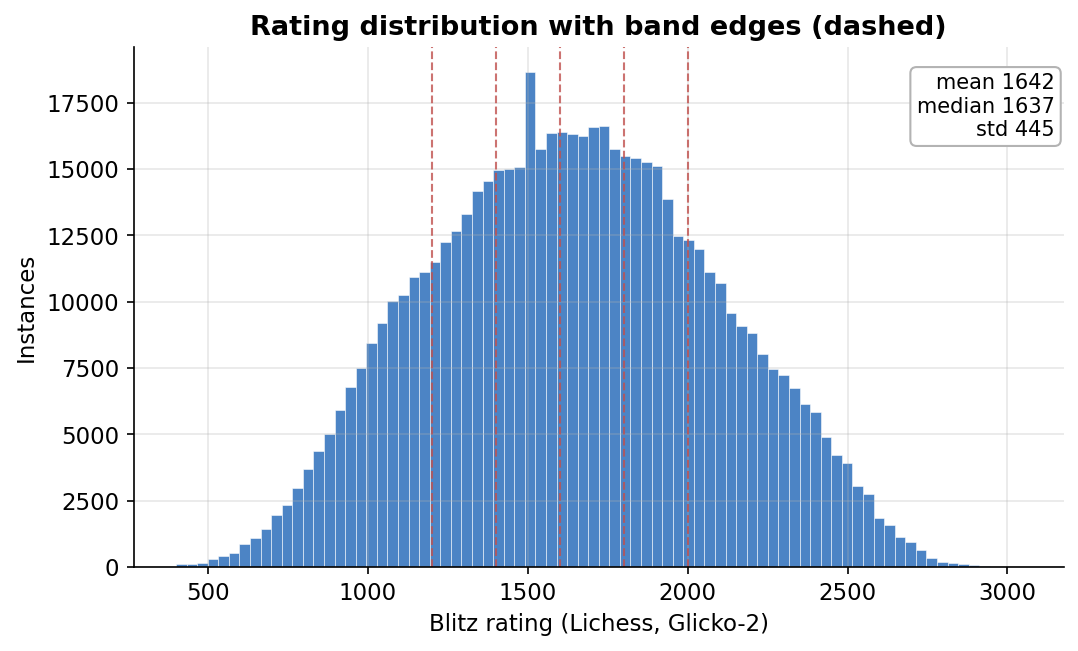

instances rated exactly 1500 (Lichess's starting rating): 3,850   at 1499 / 1501: 493 / 472


In [4]:
r = feats["rating"].to_numpy()
print(f"rating: min {r.min()}  max {r.max()}  mean {r.mean():.0f}  median {np.median(r):.0f}  std {r.std():.0f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(r, bins=80, color="#2c6fbb", alpha=0.85, edgecolor="white", linewidth=0.3)
for edge in BANDS[1:-1]:
    ax.axvline(edge, color="#c0504d", ls="--", lw=1, alpha=0.8)
ax.set(xlabel="Blitz rating (Lichess, Glicko-2)", ylabel="Instances",
       title="Rating distribution with band edges (dashed)")
ax.text(0.99, 0.95, f"mean {r.mean():.0f}\nmedian {np.median(r):.0f}\nstd {r.std():.0f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=10,
        bbox=dict(boxstyle="round", fc="white", ec="0.7"))
show(save_fig(fig, "eda_rating_distribution", FIG))
print(f"instances rated exactly 1500 (Lichess's starting rating): {(r == 1500).sum():,}   "
      f"at 1499 / 1501: {(r == 1499).sum():,} / {(r == 1501).sum():,}")

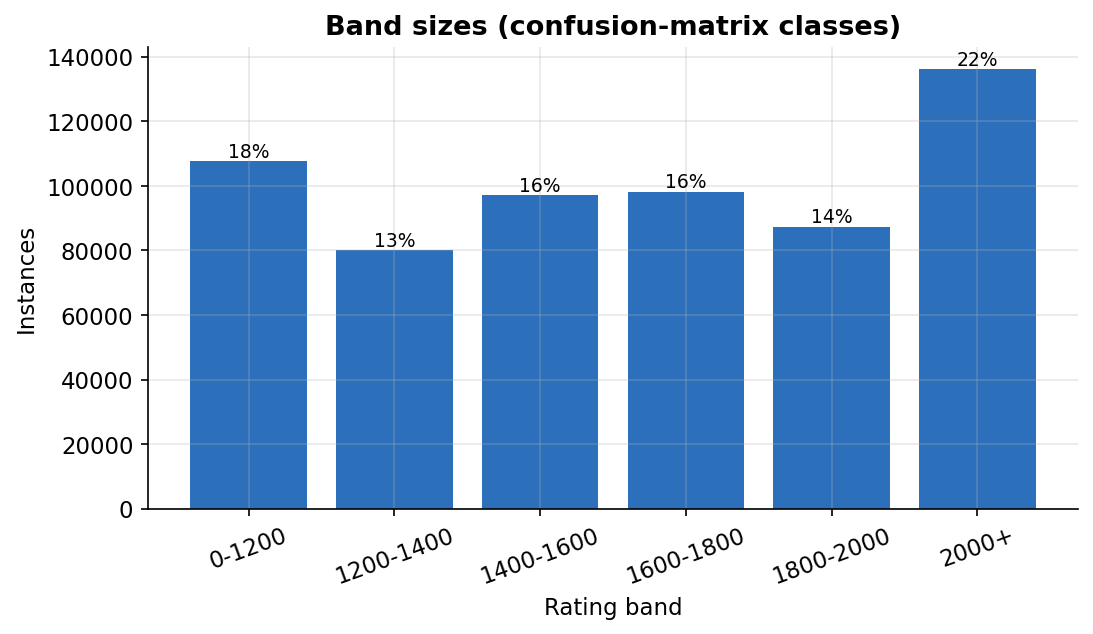

band shares: {'0-1200': np.float64(17.7), '1200-1400': np.float64(13.2), '1400-1600': np.float64(16.0), '1600-1800': np.float64(16.2), '1800-2000': np.float64(14.4), '2000-3000': np.float64(22.5)}


In [5]:
# Band sizes (the classes of the later confusion matrix).
band_idx = to_bands(r, BANDS)
counts = np.bincount(band_idx, minlength=len(LABELS))
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(LABELS[:-1] + ["2000+"], counts, color="#2c6fbb")
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, c, f"{c / len(r) * 100:.0f}%", ha="center", va="bottom", fontsize=9)
ax.set(xlabel="Rating band", ylabel="Instances", title="Band sizes (confusion-matrix classes)")
ax.tick_params(axis="x", rotation=20)
show(save_fig(fig, "eda_band_sizes", FIG))
print("band shares:", dict(zip(LABELS, np.round(counts / len(r) * 100, 1))))

**Reading it.** A bell-shaped distribution centred near 1,640 with a standard deviation of about
445. One artefact is visible in the printout: about 3,850 instances are rated exactly 1500 — the
rating every new Lichess account starts with — against about 480 at 1499 or 1501. These are new
accounts whose rating has not settled yet, a source of label noise we cannot filter (the PGN does
not mark provisional ratings). The bands are **not** equal-width: the two outer bands (below 1200, and 2000+) are wide and
together hold about **40% of all instances** — they are the two *largest* bands, not rare ones.
When later notebooks talk about "the tails", they mean these two bands. Their difficulty is not
a lack of training examples; it is that they are far from the average rating, so a model that
hedges toward the average under uncertain evidence misses them the most (notebook 05).

## 3. Games per player

A uniform sample of *games* contains mostly players seen only once:

players: 251,785   median games/player: 1   mean: 2.41   max: 187
share of players with >= 2 games: 46.9%   with >= 5: 11.1%


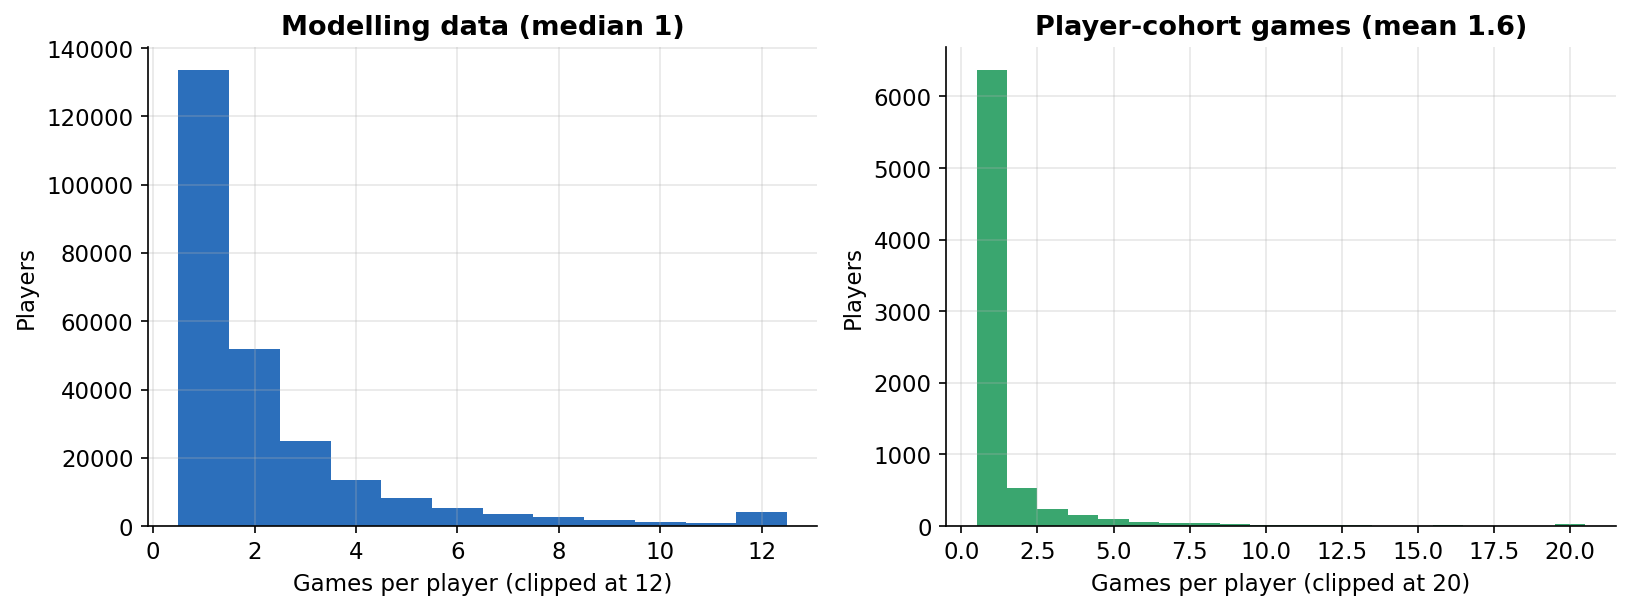

In [6]:
gpp = feats.groupby("username").size()
print(f"players: {len(gpp):,}   median games/player: {gpp.median():.0f}   mean: {gpp.mean():.2f}   max: {gpp.max()}")
print(f"share of players with >= 2 games: {(gpp >= 2).mean():.1%}   with >= 5: {(gpp >= 5).mean():.1%}")

cohort = pd.read_parquet(OUT["player_cohort"], columns=["game_id", "white", "black"])
cohort_gpp = pd.concat([cohort["white"], cohort["black"]]).value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.hist(np.clip(gpp, 0, 12), bins=np.arange(1, 14) - 0.5, color="#2c6fbb")
ax1.set(xlabel="Games per player (clipped at 12)", ylabel="Players",
        title=f"Modelling data (median {gpp.median():.0f})")
ax2.hist(np.clip(cohort_gpp, 0, 20), bins=np.arange(1, 22) - 0.5, color="#3aa66f")
ax2.set(xlabel="Games per player (clipped at 20)", ylabel="Players",
        title=f"Player-cohort games (mean {cohort_gpp.mean():.1f})")
fig.tight_layout()
show(save_fig(fig, "eda_games_per_player", FIG))

**Why this matters.** For most players there is exactly one game, so the honest task is "estimate
the rating from **one** game" — the headline metric is a single-game error with an interval. The
**player cohort** adds every in-window game of a hash-selected 0.5% of players (its right panel
counts both the cohort players and their opponents, hence the many 1s). Together with players who
simply played a lot, it gives the test set enough players with several games to ask the second
question of the project: *how much better can we do with several games of the same player?*
(notebooks 04–05). Note the window is five days, so "all games of a player" means all games in
those five days.

## 4. Move quality vs rating (the core signal)

We bin instances into 100-Elo rating slices (600–2600, slices with at least 200 instances) and plot
the mean of a feature per slice with the inter-quartile range shaded. An informative feature moves
monotonically with rating; a feature usable *from one game* would also have a narrow band.

cpl_mean: slice mean 97.5 at 650  ->  36.3 at 2550;  IQR at 650: [59.2, 124.4], at 2550: [21.8, 47.2]
acc_mean: slice mean 84.4 at 650  ->  92.0 at 2550;  IQR at 650: [79.6, 90.0], at 2550: [89.8, 94.5]


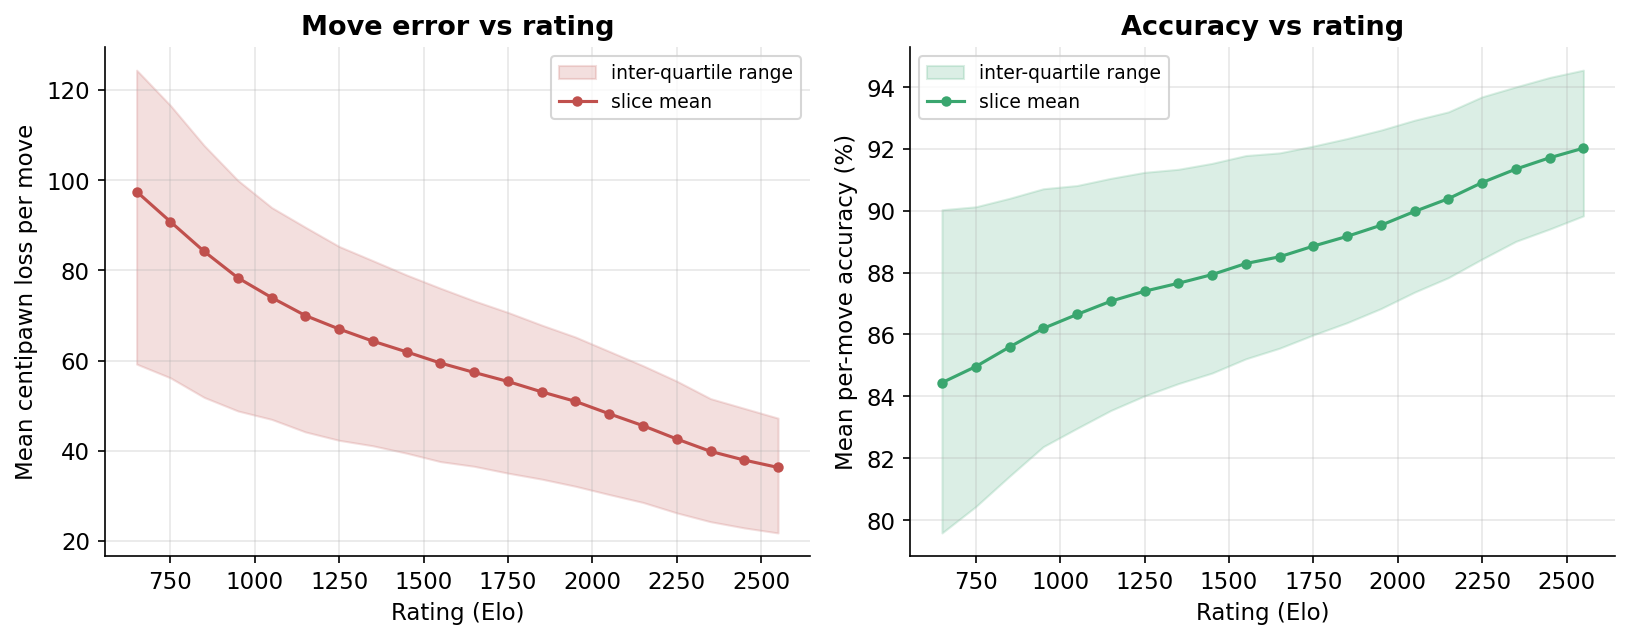

In [7]:
def rating_curve(df, col, lo=600, hi=2600, step=100, min_n=200):
    "Mean + IQR of `col` in 100-Elo rating slices (presentation helper; skips NaN and thin slices)."
    rr = df["rating"].to_numpy(float)
    vv = df[col].to_numpy(float)
    edges = np.arange(lo, hi + step, step)
    idx = np.digitize(rr, edges)
    cen, mean, q25, q75 = [], [], [], []
    for b in range(1, len(edges)):
        m = (idx == b) & ~np.isnan(vv)
        if m.sum() >= min_n:
            cen.append((edges[b - 1] + edges[b]) / 2)
            mean.append(np.mean(vv[m])); q25.append(np.percentile(vv[m], 25)); q75.append(np.percentile(vv[m], 75))
    return map(np.array, (cen, mean, q25, q75))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, col, ylab, title, color in [
    (ax1, "cpl_mean", "Mean centipawn loss per move", "Move error vs rating", "#c0504d"),
    (ax2, "acc_mean", "Mean per-move accuracy (%)", "Accuracy vs rating", "#3aa66f"),
]:
    c, m, lo, hi = rating_curve(feats, col)
    ax.fill_between(c, lo, hi, color=color, alpha=0.18, label="inter-quartile range")
    ax.plot(c, m, "-o", color=color, ms=4, label="slice mean")
    ax.set(xlabel="Rating (Elo)", ylabel=ylab, title=title)
    ax.legend(fontsize=9)
    print(f"{col}: slice mean {m[0]:.1f} at {c[0]:.0f}  ->  {m[-1]:.1f} at {c[-1]:.0f};  "
          f"IQR at {c[0]:.0f}: [{lo[0]:.1f}, {hi[0]:.1f}], at {c[-1]:.0f}: [{lo[-1]:.1f}, {hi[-1]:.1f}]")
fig.tight_layout()
show(save_fig(fig, "eda_quality_vs_rating", FIG))

**Reading it.** The slice means are close to monotone: mean centipawn loss falls from about 97
at 600–700 to about 36 at 2500–2600, and mean per-move accuracy rises from about 84% to about 92%.
*This is the signal that makes the project possible.*

But the shaded inter-quartile ranges are **wide and overlap** between neighbouring slices: a
game with a mean CPL of 50 lies inside the inter-quartile range of every slice from about 1000 to
2300 Elo. The *average* separates rating levels; a *single game* only loosely does.

(`acc_mean` is the arithmetic mean of Lichess's per-move accuracy formula. Lichess's own
game-accuracy number shown on the site aggregates the same per-move values differently.)

## 5. Blunder rate by phase

Splitting the blunder rate (moves that lose ≥ 0.30 of Lichess's winning chances, about 15 Win%
points) into opening (plies 1–30), middlegame and endgame shows *where* strength separates players.

opening   : 12.2% at 650  ->  1.2% at 2550
middlegame: 11.5% at 650  ->  5.2% at 2550
endgame   : 6.2% at 650  ->  4.9% at 2550


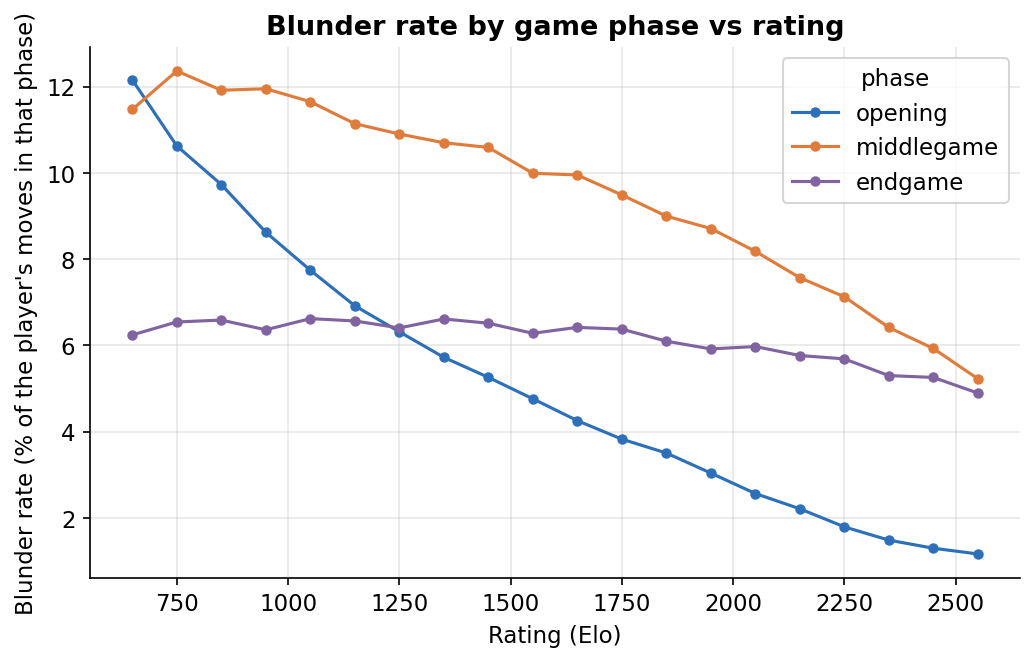

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.6))
for col, name, color in [
    ("opening_blunder_rate", "opening", "#2c6fbb"),
    ("middlegame_blunder_rate", "middlegame", "#e07b39"),
    ("endgame_blunder_rate", "endgame", "#8064a2"),
]:
    c, m, _, _ = rating_curve(feats, col)
    ax.plot(c, m * 100, "-o", ms=4, color=color, label=name)
    print(f"{name:<10}: {m[0]*100:.1f}% at {c[0]:.0f}  ->  {m[-1]*100:.1f}% at {c[-1]:.0f}")
ax.set(xlabel="Rating (Elo)", ylabel="Blunder rate (% of the player's moves in that phase)",
       title="Blunder rate by game phase vs rating")
ax.legend(title="phase")
show(save_fig(fig, "eda_blunder_by_phase", FIG))

**Reading it.**

- **Opening blunders fall the most steeply** — from about 12% of opening moves at 600–700 to about
  1% at 2500–2600, roughly a ten-fold drop. Weak players make concrete, detectable early errors
  that strong players almost never make. (Opening-quality features are also the strongest
  single linear correlates of rating, §9.)
- **The middlegame has a high blunder rate at every level** (about 11% → 5%): it is the sharpest
  phase, where even strong players err.
- **The endgame blunder rate is nearly flat** (about 6% → 5%): it separates rating levels only weakly.

This is why move quality is computed **per phase** as well as overall. About 37.5% of instances
never reach an endgame (notebook 02), which is itself information.

## 6. Time management

Every game in the modelling data carries `[%clk]` clock annotations, so time features are
observable throughout.

move_time_mean      : 6.92 at 650  ->  3.85 at 2550
fast_move_share     : 4.71 at 650  ->  15.08 at 2550
time_trouble_share  : 2.25 at 650  ->  7.17 at 2550


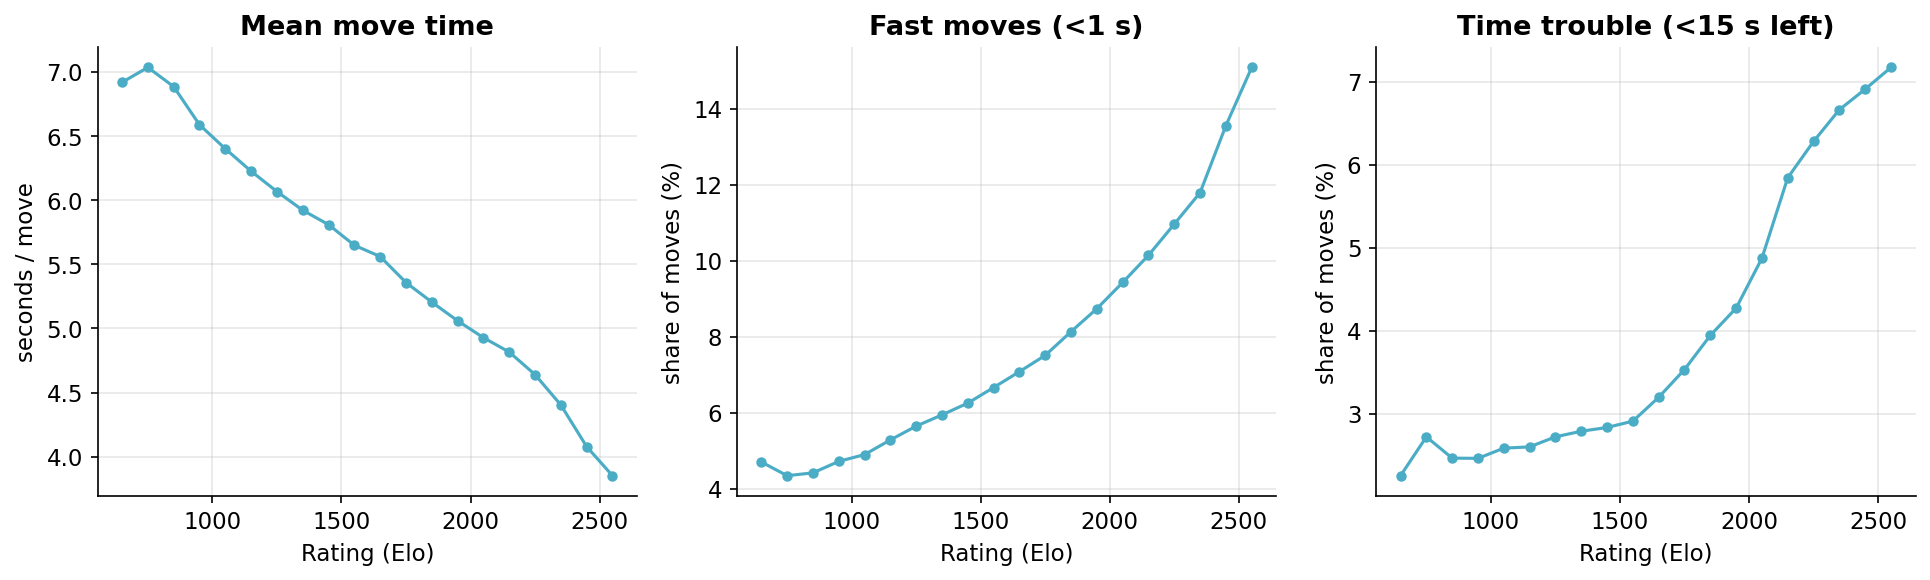

games with clock data: 100.0%


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, ylab, title in [
    (axes[0], "move_time_mean", "seconds / move", "Mean move time"),
    (axes[1], "fast_move_share", "share of moves (%)", "Fast moves (<1 s)"),
    (axes[2], "time_trouble_share", "share of moves (%)", "Time trouble (<15 s left)"),
]:
    c, m, _, _ = rating_curve(feats, col)
    y = m if col == "move_time_mean" else m * 100
    ax.plot(c, y, "-o", ms=4, color="#4bacc6")
    ax.set(xlabel="Rating (Elo)", ylabel=ylab, title=title)
    print(f"{col:<20}: {y[0]:.2f} at {c[0]:.0f}  ->  {y[-1]:.2f} at {c[-1]:.0f}")
fig.tight_layout()
show(save_fig(fig, "eda_time_vs_rating", FIG))
print(f"games with clock data: {feats['has_clock'].mean():.1%}")

**Reading it.** Stronger players move **faster**: mean move time falls from about 6.9 s to about
3.9 s across the range, and the share of near-instant (< 1 s) moves roughly triples (about 5% →
15%). The share of moves made with under 15 s left *rises* with rating (about 2% → 7%) — one
plausible reading is that strong players are more willing to play fast with little time left, but
we did not test that. Time features are also entangled with the time control (a 300+3 game allows
longer thinks than a 180+0 game), so the model combines them with move quality rather than reading
them alone; notebook 04 measures what the clock group is worth.

## 7. Opening vs post-opening accuracy

The feature set has both `opening_acc_mean` (accuracy over plies 1–30) and `acc_after_book`
(accuracy after ply 30; the name is historical — "book" here is a ply cut-off, not an opening-book
lookup). Comparing them by band shows where the accuracy gap between weak and strong players lives.

           opening_acc_mean  acc_after_book
_band                                      
0-1200                85.86           86.37
1200-1400             88.00           86.49
1400-1600             89.00           86.69
1600-1800             89.99           86.88
1800-2000             90.88           87.43
2000-3000             93.01           88.69


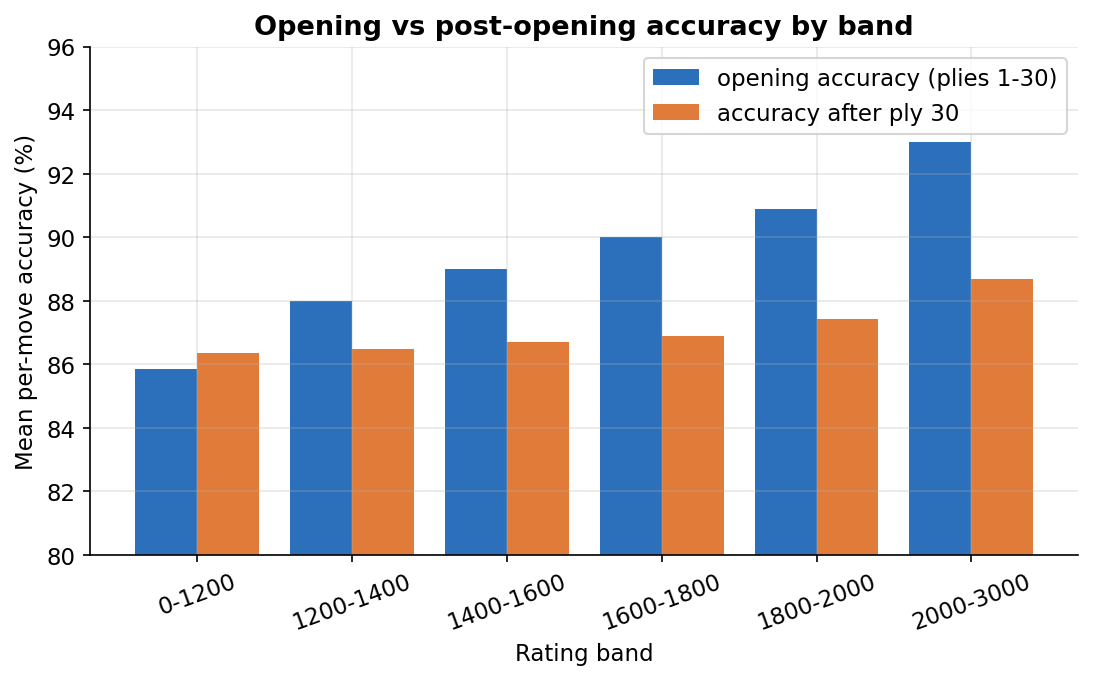

In [10]:
feats["_band"] = pd.Categorical(np.array(LABELS)[to_bands(feats["rating"], BANDS)], categories=LABELS)
by_band = feats.groupby("_band", observed=True)[["opening_acc_mean", "acc_after_book"]].mean()
print(by_band.round(2))

fig, ax = plt.subplots(figsize=(8.5, 4.4))
x = np.arange(len(by_band))
ax.bar(x - 0.2, by_band["opening_acc_mean"], width=0.4, label="opening accuracy (plies 1-30)", color="#2c6fbb")
ax.bar(x + 0.2, by_band["acc_after_book"], width=0.4, label="accuracy after ply 30", color="#e07b39")
ax.set_xticks(x); ax.set_xticklabels(by_band.index, rotation=20)
ax.set(xlabel="Rating band", ylabel="Mean per-move accuracy (%)", title="Opening vs post-opening accuracy by band")
ax.set_ylim(80, 96); ax.legend()
show(save_fig(fig, "eda_book_depth", FIG))

**Reading it.** The accuracy gap is widest in the **opening**: `opening_acc_mean` goes from about
85.9% in the lowest band to about 93.0% in the highest (a 7-point spread), while accuracy after
ply 30 moves only from about 86.4% to 88.7%. How cleanly a player handles the first 15 moves is the
strongest single linear signal of rating. After the opening, positions are sharper for everyone and
accuracies compress. This does not make the later-game features useless — a tree model can use them
in combination — which notebook 04 checks with SHAP and ablations.

## 8. The opponent-rating leak (why matchmaking must be excluded)

Lichess pairs players of similar rating, so the opponent's rating is a near-copy of yours. Any
feature derived from the opponent would smuggle the label into the model. We show the leak here
to justify **excluding** it.

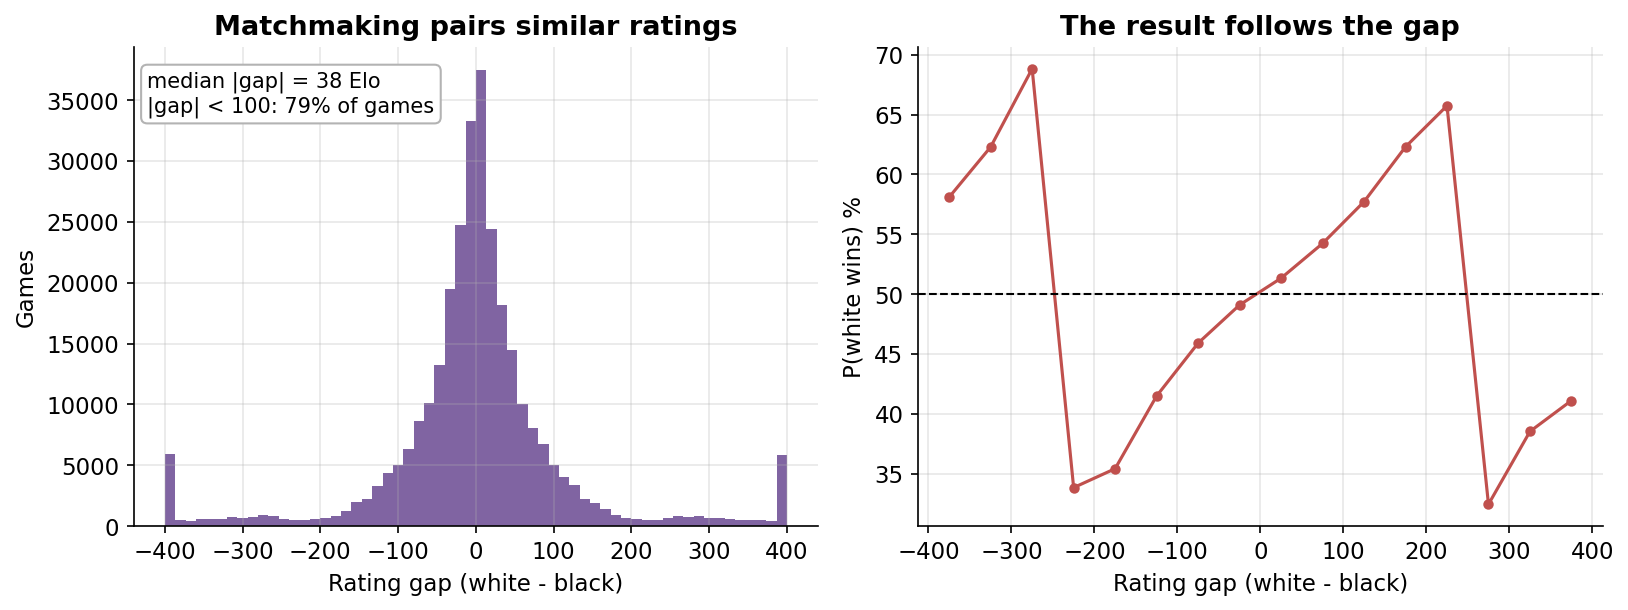

In [11]:
gap = (games["white_elo"] - games["black_elo"]).to_numpy(float)
white_win = (games["result"] == "1-0").to_numpy(float)

edges = np.arange(-400, 401, 50)           # P(white wins) vs rating gap, 50-Elo bins
idx = np.digitize(gap, edges)
cen, pwin = [], []
for b in range(1, len(edges)):
    m = idx == b
    if m.sum() >= 200:
        cen.append((edges[b - 1] + edges[b]) / 2); pwin.append(white_win[m].mean())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.hist(np.clip(gap, -400, 400), bins=60, color="#8064a2")
ax1.set(xlabel="Rating gap (white - black)", ylabel="Games", title="Matchmaking pairs similar ratings")
ax1.text(0.02, 0.95, f"median |gap| = {np.median(np.abs(gap)):.0f} Elo\n|gap| < 100: {(np.abs(gap) < 100).mean():.0%} of games",
         transform=ax1.transAxes, va="top", fontsize=10, bbox=dict(boxstyle="round", fc="white", ec="0.7"))
ax2.plot(cen, np.array(pwin) * 100, "-o", color="#c0504d", ms=4)
ax2.axhline(50, color="k", ls="--", lw=1)
ax2.set(xlabel="Rating gap (white - black)", ylabel="P(white wins) %", title="The result follows the gap")
fig.tight_layout()
show(save_fig(fig, "eda_opponent_leak", FIG))

**Reading it.** Games cluster tightly around a zero rating gap (median |gap| about 38 Elo; about 80%
of games within 100). Within ±250 (about 92% of games) the win probability rises smoothly with the
gap. So *opponent rating ≈ your rating*. (Beyond ±250 the curve inverts — the *lower*-rated player
wins more often. Such large gaps are rare and plausibly involve mis-rated accounts, e.g. new players
still near the 1500 starting rating; we did not investigate further.) That is why every instance drops the opponent's rating and username
(`clean.INSTANCE_COLUMNS`), why features describe **only the player's own moves and clock**, and why
train/test splits are grouped by `username`. The opponent rating is reconstructed in one place only
— `model.add_opponent_rating` — to *measure* the leak as the "copy-opponent" reference in notebook 03.

## 9. Feature ↔ rating correlation map

A bird's-eye view of how the main features correlate with rating and with each other (Pearson).

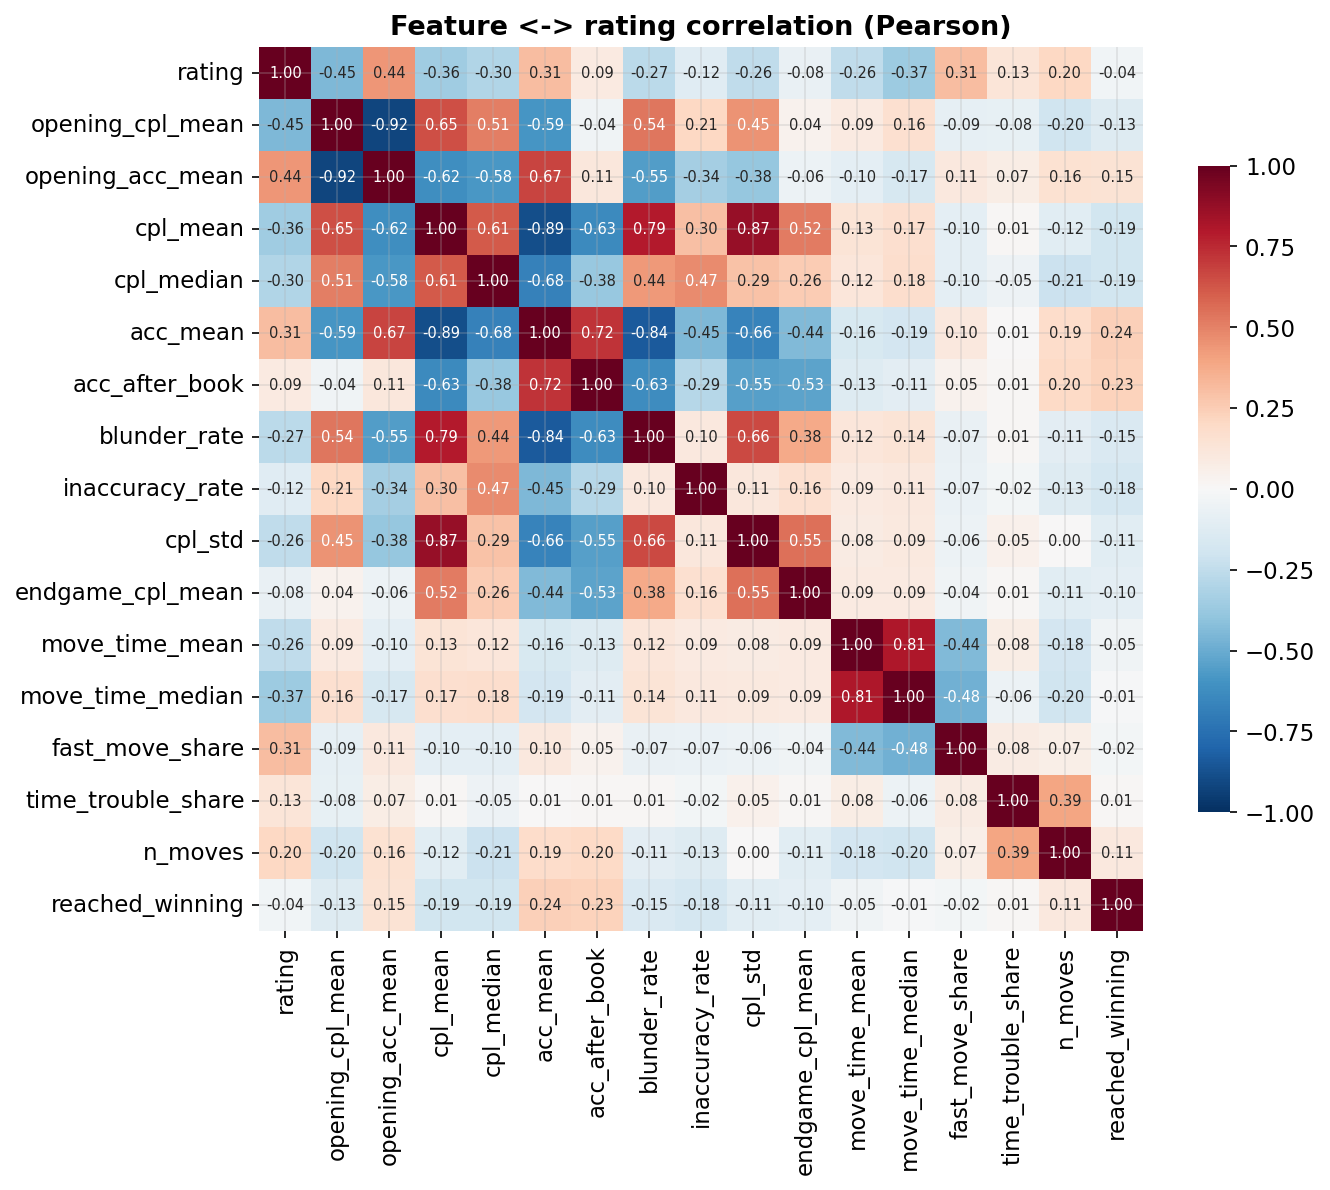

Correlation with rating (features shown), sorted by magnitude:
opening_cpl_mean     -0.446
opening_acc_mean      0.440
move_time_median     -0.367
cpl_mean             -0.359
acc_mean              0.308
fast_move_share       0.306
cpl_median           -0.299
blunder_rate         -0.266
cpl_std              -0.257
move_time_mean       -0.256
n_moves               0.204
time_trouble_share    0.132
inaccuracy_rate      -0.121
acc_after_book        0.091
endgame_cpl_mean     -0.077
reached_winning      -0.037



Strongest 8 of all 73 numeric features:
opening_cpl_mean        -0.446
opening_acc_mean         0.440
opening_cpl_std         -0.388
opening_cpl_max         -0.371
move_time_median        -0.367
cpl_mean                -0.359
opening_blunder_rate    -0.345
opening_blunder_count   -0.344


In [12]:
key = ["rating", "opening_cpl_mean", "opening_acc_mean", "cpl_mean", "cpl_median", "acc_mean", "acc_after_book",
       "blunder_rate", "inaccuracy_rate", "cpl_std", "endgame_cpl_mean",
       "move_time_mean", "move_time_median", "fast_move_share", "time_trouble_share", "n_moves", "reached_winning"]
corr = feats[key].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.7}, ax=ax, annot_kws={"size": 7})
ax.set_title("Feature <-> rating correlation (Pearson)")
show(save_fig(fig, "eda_correlation_heatmap", FIG))

print("Correlation with rating (features shown), sorted by magnitude:")
print(corr["rating"].drop("rating").sort_values(key=abs, ascending=False).round(3).to_string())
num_cols = feats.select_dtypes("number").columns.drop("rating")
all_corr = feats[num_cols].corrwith(feats["rating"]).sort_values(key=abs, ascending=False)
print("\nStrongest 8 of all 73 numeric features:")
print(all_corr.head(8).round(3).to_string())

**Reading it.** No single feature is enough. The strongest linear correlates of rating in the
whole feature set are opening-quality features — `opening_cpl_mean` (−0.45) and `opening_acc_mean`
(+0.44), then the opening CPL spread and maximum — followed by `move_time_median` (−0.37) and
`cpl_mean` (−0.36).
The move-quality features are strongly correlated *with each other* — different views of "how many
good moves did you find" — so their information overlaps; clock and style features add smaller,
partly independent pieces. With the best single correlation around 0.44, a single game can only
be read loosely, which is why the model combines many features non-linearly (notebook 04) and
reports an interval rather than just a point.

## 10. The tension, in one chart

A clearly rating-related feature, `cpl_mean`, shown as a distribution *within* each band. If one
game were enough, these distributions would be well separated. They overlap heavily.

shown: 95.1% of instances (cpl_mean < 120)


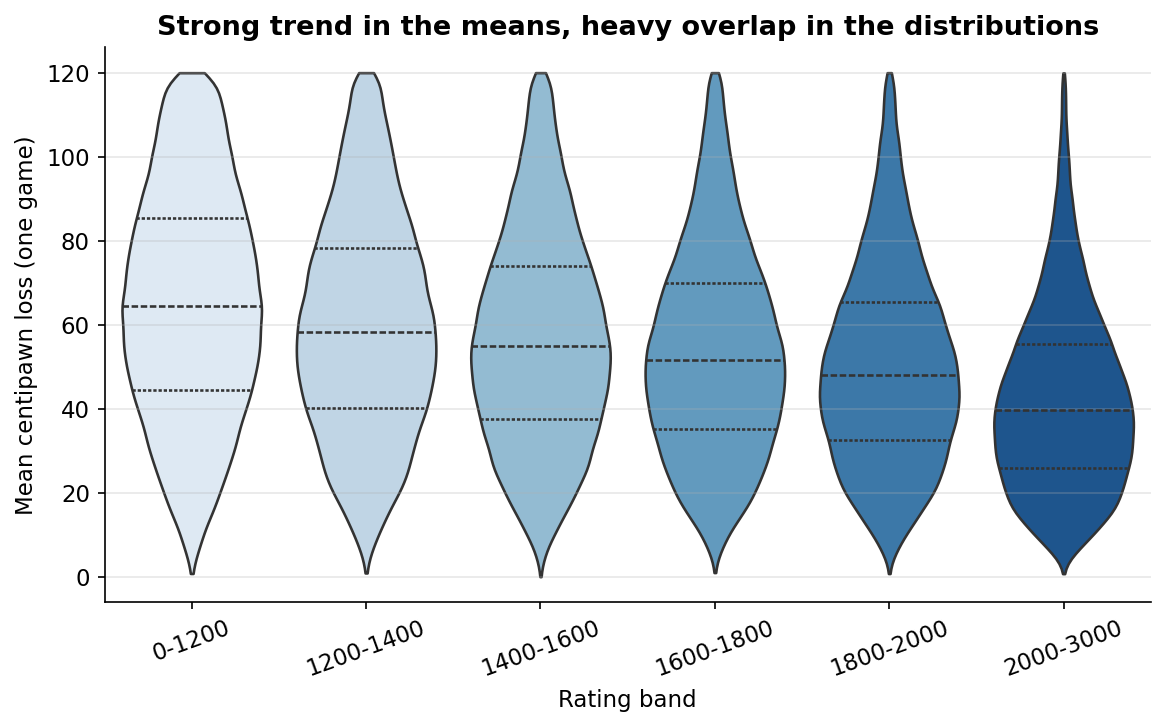

In [13]:
sub = feats[feats["cpl_mean"] < 120]                # clip a thin high-CPL tail for readability
print(f"shown: {len(sub) / len(feats):.1%} of instances (cpl_mean < 120)")
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.violinplot(data=sub, x="_band", y="cpl_mean", order=LABELS, cut=0,
               palette="Blues", inner="quartile", ax=ax)
ax.set(xlabel="Rating band", ylabel="Mean centipawn loss (one game)",
       title="Strong trend in the means, heavy overlap in the distributions")
ax.tick_params(axis="x", rotation=20)
show(save_fig(fig, "eda_cpl_overlap_by_band", FIG))

## Takeaways

- **The data:** first five days of May 2025, blitz games that carry stored Stockfish evaluations
  (about 9% of blitz games), reservoir-sampled to 300k games plus a player cohort, stored as
  parquet. It is a self-selected subset, not a random sample of blitz.
- **The signal is real.** Move quality (CPL, accuracy, opening accuracy, blunder rate) tracks rating
  clearly and monotonically on average.
- **The noise is larger.** Every one of those features overlaps heavily between rating levels in a
  single game — the driving tension of the project.
- **Where the signal lives:** the opening separates players most; the endgame least.
- **The opponent is off-limits.** Matchmaking makes the opponent's rating a near-copy of the label;
  the feature set and the grouped splits are built to keep it out.

**Next:** notebook 02 shows how a raw PGN becomes the 77-feature vector these plots used.